In [6]:
import os
import sys

# Ruta absoluta a la carpeta pywdf/pywdf
root_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "pywdf", "pywdf"))
sys.path.insert(0, root_dir)

from core.wdf import *
from core.circuit import Circuit


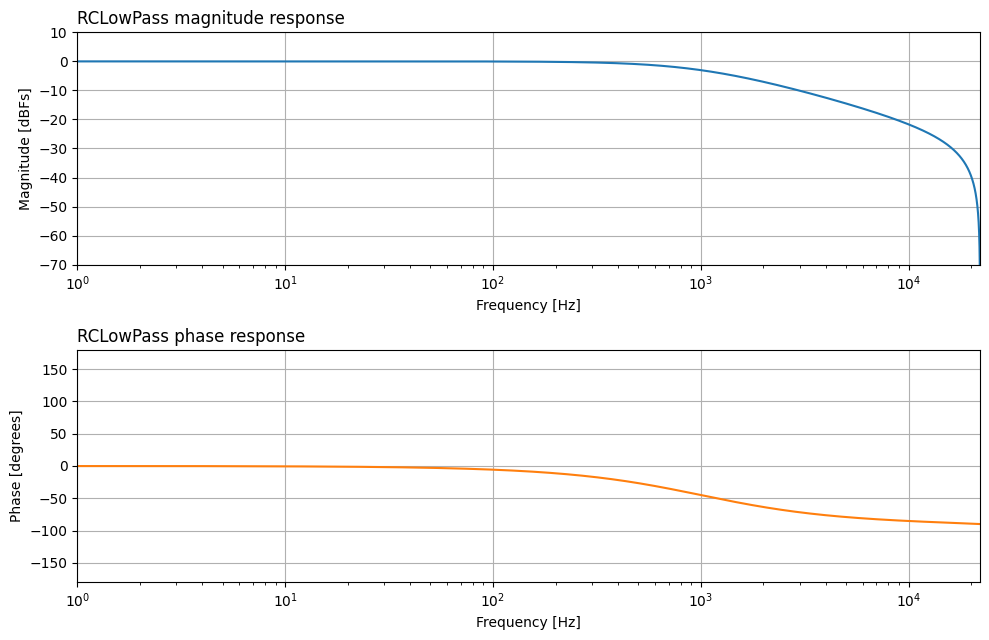

cutoff : 1000
cutoff : 2000
cutoff : 3000
cutoff : 4000
cutoff : 5000
cutoff : 6000
cutoff : 7000
cutoff : 8000
cutoff : 9000


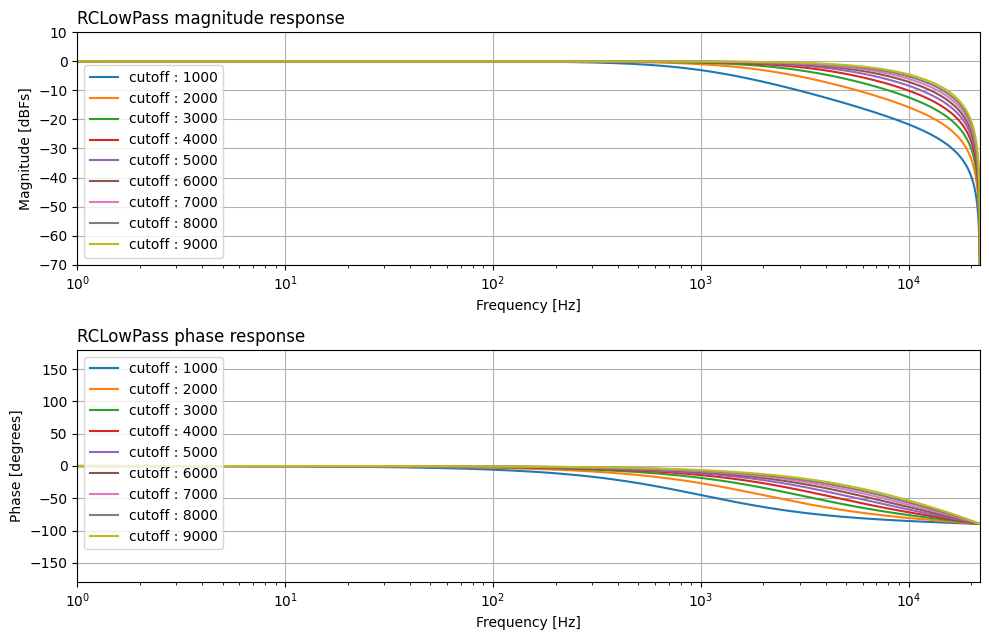

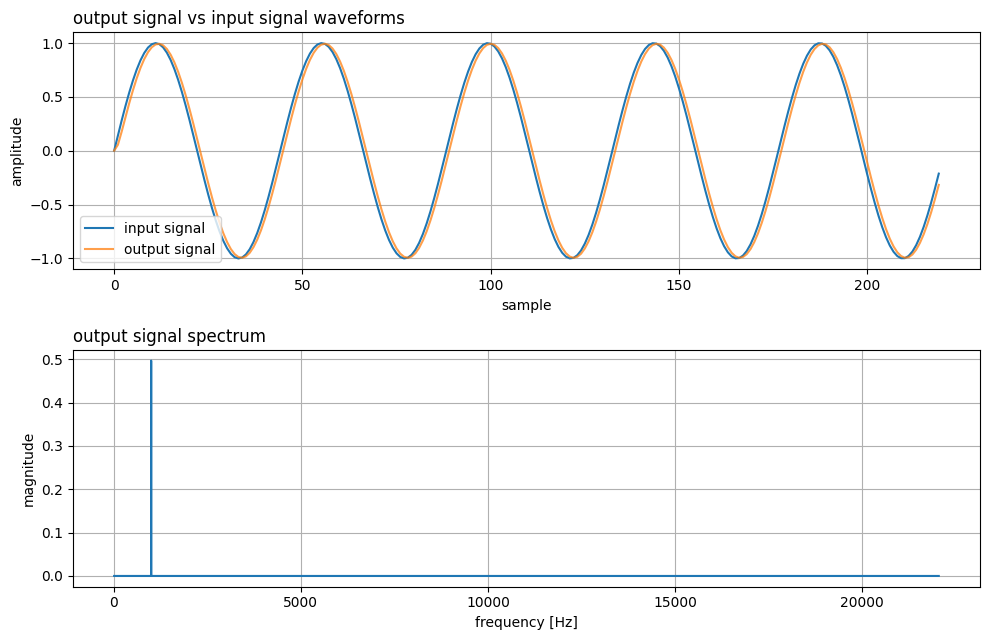

In [7]:
class RCLowPass(Circuit):
    def __init__(self, sample_rate: int, cutoff: float) -> None:

        self.fs = sample_rate
        self.cutoff = cutoff

        self.C = 1e-6
        self.R = 1.0 / (2 * np.pi * self.C * self.cutoff)

        self.R1 = Resistor(self.R)
        self.C1 = Capacitor(self.C, self.fs)

        self.S1 = SeriesAdaptor(self.R1, self.C1)
        self.I1 = PolarityInverter(self.S1)
        self.Vs = IdealVoltageSource(self.I1)

        super().__init__(self.Vs, self.Vs, self.C1)

    def set_cutoff(self, new_cutoff: float):
        if self.cutoff != new_cutoff:
            self.cutoff = new_cutoff
            self.R = 1.0 / (2 * np.pi * self.C * self.cutoff)
            self.R1.set_resistance(self.R)


if __name__ == "__main__":
    lpf = RCLowPass(44100, 1000)
    lpf.plot_freqz()
    lpf.plot_freqz_list(range(1000, 10000, 1000), lpf.set_cutoff, param_label="cutoff")
    lpf.AC_transient_analysis()
